<a href="https://colab.research.google.com/github/joseph-4640/Air-Quality-Prediction/blob/main/CHEST_CANCER_DETECTION~PYTORCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT DATA**

In [ ]:
import pandas as pd
import os
import sys

import cv2
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
!pip install torchinfo
import PIL
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader
from torchinfo import summary
from torchvision import datasets, transforms, models
from tqdm.notebook import tqdm
torch.backends.cudnn.deterministic = True

**Versions of the packages used**

In [ ]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("matplotlib version:", matplotlib.__version__)
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
---
matplotlib version: 3.10.0
pandas version: 2.2.2
PIL version: 11.1.0
torch version: 2.5.1+cu124
torchvision version: 0.20.1+cu124


In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


**DOWNLOADING DATASET FROM KAGGLE**

In [ ]:
import shutil

# Create the .kaggle directory if not exists
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json to the .kaggle folder, only if it doesn't already exist
if not os.path.exists("/root/.kaggle/kaggle.json"):
    shutil.move("/content/kaggle.json", "/root/.kaggle")
else:
    print("kaggle.json already exists in /root/.kaggle, skipping move.")
# Set correct permissions
os.chmod("/root/.kaggle/kaggle.json", 600)


kaggle.json already exists in /root/.kaggle, skipping move.


In [ ]:
!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images


Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
chest-ctscan-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile

with zipfile.ZipFile("/content/chest-ctscan-images.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/chest-ctscan-images")


# **DATA EXPLORATION**

**ASSIGN DIRECTORIES**

In [ ]:
data_dir = os.path.join("chest-ctscan-images", "Data")
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")
val_dir = os.path.join(data_dir, "val")

**List Train Directory Claasses**

In [ ]:
files = os.listdir(val_dir)
print(files)

['large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


**CHEST SCAN IMAGES SAMPLE**


This function opens and displays five randomly selected images with PIL library.

In [ ]:
import random

def sample_images(data_path, classname):
    # Gets the files in the directory
    class_dir = os.path.join(data_path, classname)
    if not os.path.exists(class_dir):
        return "Invalid directory"
    image_list = os.listdir(class_dir)
    if len(image_list) < 4:
        return "Not enough images in folder"

    # Pick four random images
    images_sample = random.sample(image_list, 5)

    # Plot them
    plt.figure(figsize=(20, 20))
    for i in range(5):
        img_loc = os.path.join(class_dir, images_sample[i])
        img = PIL.Image.open(img_loc)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")

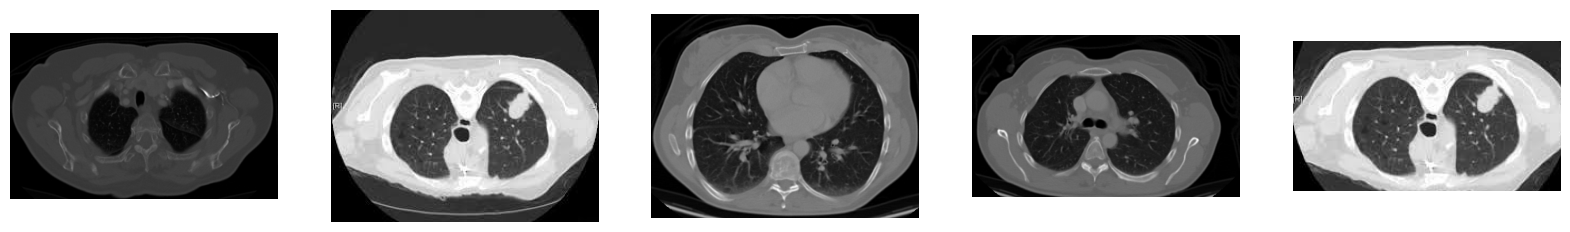

In [ ]:
sample_images(train_dir, "adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib")

# **PREPARE DATA**

**TRANSFORMATION PIPELINE**

The transformation pipeline;


*   Converts images from greyscale RGB
*   Resize the images

*   Convert images to pytorch tensors





In [ ]:
class ConvertToRGB:
  def __call__(self, img):
      if img != "RGB":
        img = img.convert("RGB")
      return img

In [ ]:
transform = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

**IMAGE FOLDER**

Image Folder tool enables us to open the files and apply the transformations

In [ ]:
dataset = datasets.ImageFolder(root=train_dir, transform=transform)
print("classes")
print(dataset.classes)
print("Shape of one tensor")
print(dataset[0][0].shape)

classes
['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Shape of one tensor
torch.Size([3, 224, 224])


**DATA LOADER**

In [ ]:
batch_size=32
dataset_loader = DataLoader(dataset, batch_size=batch_size)
# Create one batch
one_batch = next(iter(dataset_loader))
print("Shape of one batch")
print(one_batch[0].shape)

Shape of one batch
torch.Size([32, 3, 224, 224])


**EXTRACT CHANNEL STATISTICS**

In [ ]:
def get_mean_std(loader):
    """Computes the mean and standard deviation of image data.

    Input: a `DataLoader`.
    Output: the mean of each channel as a tensor, the standard deviation of each channel as a tensor
            formatted as a tuple."""

    channels_sum, channels_squared_sum, num_batches = 0, 0, 0
    for data, _ in tqdm(loader, desc="Computing mean and std", leave=False):
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1
    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2) ** 0.5

    return mean, std

In [ ]:
mean, std = get_mean_std(dataset_loader)
print(mean)
print(std)

Computing mean and std:   0%|          | 0/20 [00:00<?, ?it/s]

tensor([0.3256, 0.3255, 0.3256])
tensor([0.2676, 0.2676, 0.2676])


**TRANSFORMATION PIPELINE: NORMALIZATION**

In [ ]:
transform_norm = transforms.Compose(
    [
        ConvertToRGB(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]
)

**TRAIN AND VALIDATION LOADERS**

In [ ]:
batch_size=32
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform_norm)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform_norm)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

**TRAIN AND VALIDATION DISTRIBUTION**

In [ ]:
def class_counts(dataset):
    # Count occurrences of each class
    c = Counter(x[1] for x in tqdm(dataset))

    # Get class to index mapping from the dataset itself
    class_to_index = dataset.class_to_idx

    # Create a dictionary of class counts with class names as keys
    class_counts_dict = {class_name: c.get(class_index, 0)
                         for class_name, class_index in class_to_index.items()}

    # Return a Series with class names as index and counts as values
    return pd.Series(class_counts_dict, index=class_to_index.keys())

  0%|          | 0/613 [00:00<?, ?it/s]

adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib          195
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       115
normal                                              148
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa    155
dtype: int64


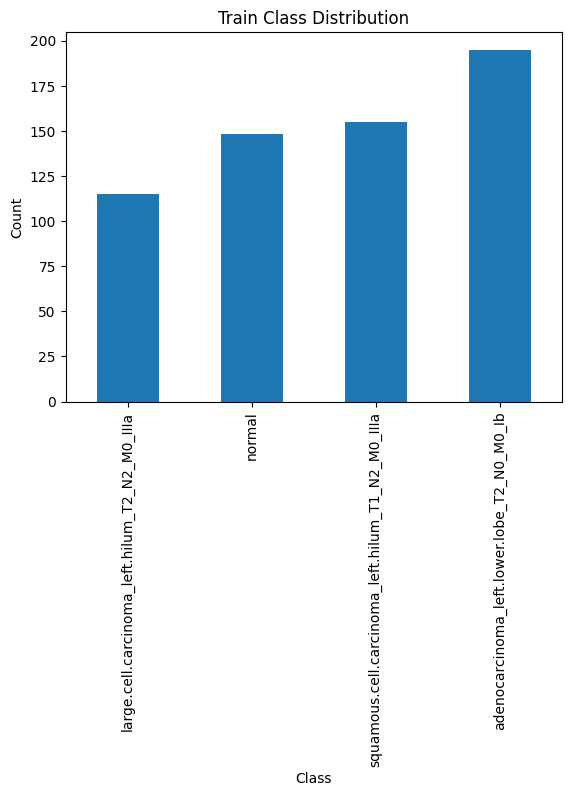

In [ ]:
train_class_distibution = class_counts(train_dataset)
print(train_class_distibution)
train_class_distibution.sort_values().plot(kind="bar")
plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show();

  0%|          | 0/72 [00:00<?, ?it/s]

adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib          23
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       21
normal                                              13
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa    15
dtype: int64


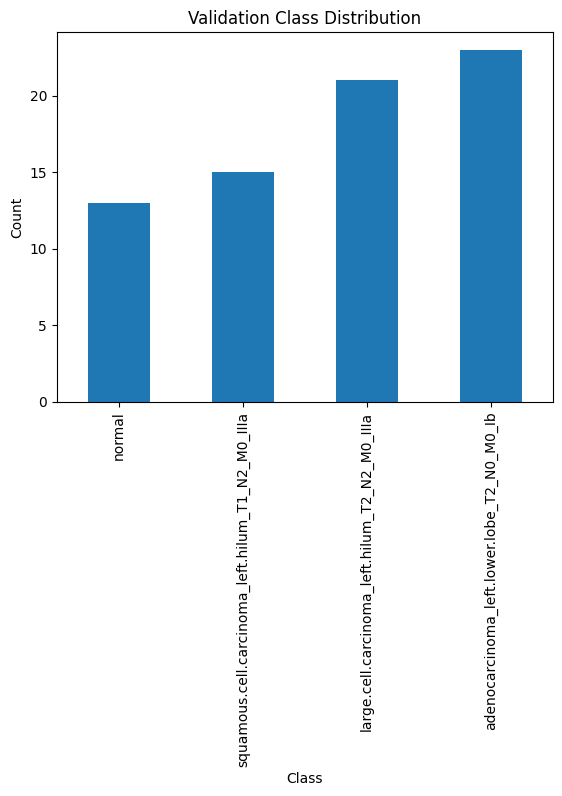

In [ ]:
val_class_distibution = class_counts(val_dataset)
print(val_class_distibution)
val_class_distibution.sort_values().plot(kind="bar")
plt.title("Validation Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show();

# **SHALLOW NEURAL NETWORK**

**BUILDING A CNN**

In [ ]:
model = nn.Sequential(
    # First layer
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    # Second layer
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    # Third layer
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    # Flattening
    nn.Flatten(),
    nn.Dropout(0.5),
    # Fully connected layers
    nn.Linear(64 * 28 * 28, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    # Output layer
    nn.Linear(512, 4),
)

In [ ]:
summary(model, input_size=(batch_size, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 4]                   --
├─Conv2d: 1-1                            [32, 16, 224, 224]        448
├─ReLU: 1-2                              [32, 16, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 16, 112, 112]        --
├─Conv2d: 1-4                            [32, 32, 112, 112]        4,640
├─ReLU: 1-5                              [32, 32, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 32, 56, 56]          --
├─Conv2d: 1-7                            [32, 64, 56, 56]          18,496
├─ReLU: 1-8                              [32, 64, 56, 56]          --
├─MaxPool2d: 1-9                         [32, 64, 28, 28]          --
├─Flatten: 1-10                          [32, 50176]               --
├─Dropout: 1-11                          [32, 50176]               --
├─Linear: 1-12                           [32, 512]                 25,690,624

**TRAINING THE MODEL**

**OPTIMIZER AND LOSS FUNCTION**

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_epoch(model, optimizer, loss_fn, data_loader, device="cpu"):
    # We'll report the loss function's average value at the end of the epoch.
    training_loss = 0.0

    # The train method simply sets the model in training mode. No training
    # has happened.
    model.train()

    # We iterate over all batches in the training set to complete one epoch
    for inputs, targets in tqdm(data_loader, desc="Training", leave=False):
        # Sets the gradients to zero. We need to do this every time.
        optimizer.zero_grad()

        # Unpack images (X) and labels (y) from the batch and add those
        # tensors to the specified device.
        inputs = inputs.to(device)
        targets = targets.to(device)

        # We make a forward pass through the network and obtain the logits.
        # With the logits, we can calculate our loss.
        output = model(inputs)
        loss = loss_fn(output, targets)

        # After calculating our loss, we calculate the numerical value of
        # the derivative of our loss function with respect to all the
        # trainable model weights. Once we have the gradients calculated,
        # we let the optimizer take a "step", in other words, update or
        # adjust the model weights.
        loss.backward()
        optimizer.step()

        # We increment the training loss for the current batch
        training_loss += loss.data.item() * inputs.size(0)

    # We calculate the training loss over the completed epoch
    return training_loss / len(data_loader.dataset)


In [ ]:
def score(model, data_loader, loss_fn, device="cpu"):
    # Initialize the total loss (cross entropy) and the number of correct
    # predictions. We'll increment these values as we loop through the
    # data.
    total_loss = 0
    total_correct = 0

    # We set the model to evaluation mode. This mode is the opposite of
    # train mode we set in the train_epoch function.
    model.eval()

    # Since we're not training, we don't need any gradient calculations.
    # This tells PyTorch not to calculate any gradients, which speeds up
    # some calculations.
    with torch.no_grad():
        # We iterate over the batches in the data loader and feed
        # them into the model for the forward pass.
        for inputs, targets in tqdm(data_loader, desc="Scoring", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # Calculating the loss function for this batch
            targets = targets.to(device)
            loss = loss_fn(output, targets)
            total_loss += loss.data.item() * inputs.size(0)

            # Calculating the correct predictions for this batch
            correct = torch.eq(torch.argmax(output, dim=1), targets)
            total_correct += torch.sum(correct).item()

    return total_loss / len(data_loader.dataset), total_correct / len(
        data_loader.dataset
    )


In [ ]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):
    train_losses = []
    valid_losses = []
    train_accuracies = []  # Initialize to store train accuracies
    valid_accuracies = []  # Initialize to store validation accuracies

    for epoch in range(1, epochs + 1):
        # Run train_epoch once, and capture the training loss.
        training_loss = train_epoch(model, optimizer, loss_fn, train_loader, device)
        train_losses.append(training_loss)  # Append to train_losses

        # Score the model on the validation data.
        validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)
        valid_losses.append(validation_loss)

        # Append accuracies
        train_accuracies.append(0)
        valid_accuracies.append(validation_accuracy)

        print(
            f"Epoch: {epoch}, Training Loss: {training_loss:.2f}, "
            f"Validation Loss: {validation_loss:.2f}, Validation Accuracy: {validation_accuracy:.2f}"
        )

    return train_losses, valid_losses, train_accuracies, valid_accuracies # Return the lists


In [ ]:
train_losses, valid_losses, train_accuracies, valid_accuracies = train(model, optimizer, loss_fn, train_loader, val_loader, epochs=10, device=device)

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Scoring:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 1.15, Validation Loss: 0.90, Validation Accuracy: 0.67


Training:   0%|          | 0/20 [00:00<?, ?it/s]

Scoring:   0%|          | 0/3 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 9, Training Loss: 0.10, Validation Loss: 0.63, Validation Accuracy: 0.81


Training:   0%|          | 0/20 [00:00<?, ?it/s]

Scoring:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 10, Training Loss: 0.07, Validation Loss: 0.60, Validation Accuracy: 0.79


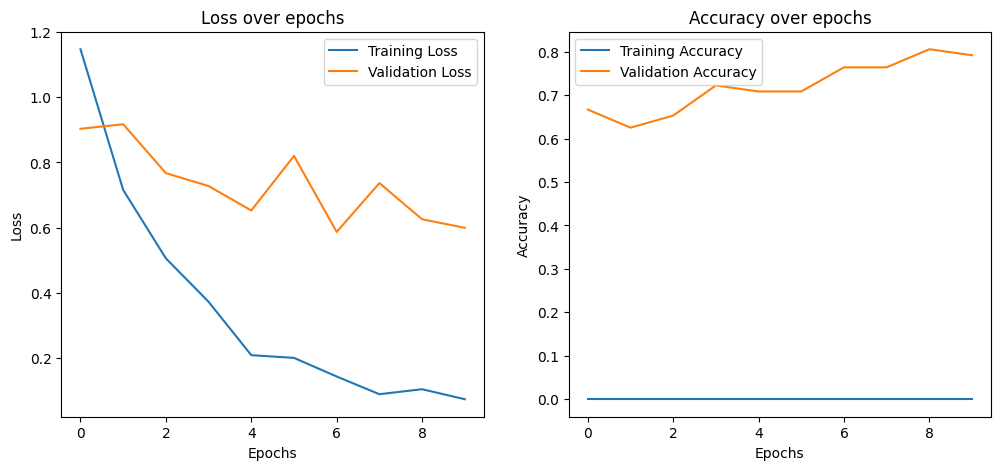

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")
plt.title("Loss over epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(valid_accuracies, label="Validation Accuracy")
plt.title("Accuracy over epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# **TRANSFER LEARNING**

In [ ]:
model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


**MODEL**

In [ ]:
summary(model, input_size=(batch_size, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 1000]                --
├─Conv2d: 1-1                            [32, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        128
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          4,096
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          36,864
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          128
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]          --
│ 

In [ ]:
# Turn off updating during backpropagation
for params in model.parameters():
  params.requires_grad = False

In [ ]:
# Move the model to device
model = model.to(device)

**INPUT FEATURE EXTRACTION**

In [ ]:
list(model.named_modules())[-1]
in_features = model.fc.in_features

**LINEAR LAYER ADDITION**

In [ ]:
classifier = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 4),
)
# Remove the output in Resnet50 model with classifier
model.fc = classifier

In [ ]:
summary(model, input_size=(batch_size, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 4]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 256, 56, 56]         --
│    └─Bottleneck: 2-1                   [32, 256, 56, 56]         --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (4,096)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]   

**TRAINING THE MODEL WITH CALLBACKS**

**Learning Rate Scheduler**

In [ ]:
# Period of learning rate decay
step_size = 4
# Multiplicative factor of learning rate decay
gamma = 0.2

# Initialize the learning rate scheduler
scheduler = StepLR(
    optimizer,
    step_size=step_size,
    gamma=gamma,
)

print(type(scheduler))

<class 'torch.optim.lr_scheduler.StepLR'>


**Early Stopping**

In [ ]:
def early_stopping(validation_loss, best_val_loss, counter):
    """Function that implements Early Stopping"""

    stop = False

    if validation_loss < best_val_loss:
        counter = 0
    else:
        counter += 1

    # Check if counter is >= patience (5 epochs in our case)
    # Set stop variable accordingly
    if counter >= 5:
        stop = True

    return counter, stop

**Checkpointing Function**

In [ ]:
def checkpointing(validation_loss, best_val_loss, model, optimizer, save_path):

    # Create the directory if it doesn't exist
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    if validation_loss < best_val_loss:
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": best_val_loss,
            },
            save_path,
        )
        print(f"Checkpoint saved with validation loss {validation_loss:.4f}")

**TRAINING**

In [ ]:
def train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=20,
    device="cpu",
    scheduler=None,
    checkpoint_path=None,
    early_stopping=None,
):
    # Track the model progress over epochs
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []
    learning_rates = []

    # Create the trackers if needed for checkpointing and early stopping
    best_val_loss = float("inf")
    early_stopping_counter = 0

    print("Model evaluation before start of training...")
    # Test on training set
    train_loss, train_accuracy = score(model, train_loader, loss_fn, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    # Test on validation set
    validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)
    val_losses.append(validation_loss)
    val_accuracies.append(validation_accuracy)

    for epoch in range(1, epochs + 1):
        print("\n")
        print(f"Starting epoch {epoch}/{epochs}")

        # Train one epoch
        train_epoch(model, optimizer, loss_fn, train_loader, device)

        # Evaluate training results
        train_loss, train_accuracy = score(model, train_loader, loss_fn, device)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Test on validation set
        validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)
        val_losses.append(validation_loss)
        val_accuracies.append(validation_accuracy)

        print(f"Epoch: {epoch}")
        print(f"Training loss: {train_loss:.4f}")
        print(f"Training accuracy: {train_accuracy*100:.4f}%")
        print(f"Validation loss: {validation_loss:.4f}")
        print(f"Validation accuracy: {validation_accuracy*100:.4f}%")

        # # Log the learning rate and have the scheduler adjust it
        lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(lr)
        if scheduler:
            scheduler.step()

        # Checkpointing saves the model if current model is better than best so far
        if checkpoint_path:
            checkpointing(
                validation_loss, best_val_loss, model, optimizer, checkpoint_path
            )

        # Early Stopping
        if early_stopping:
            early_stopping_counter, stop = early_stopping(
                validation_loss, best_val_loss, early_stopping_counter
            )
            if stop:
                print(f"Early stopping triggered after {epoch} epochs")
                break

        if validation_loss < best_val_loss:
            best_val_loss = validation_loss

    return (
        learning_rates,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies,
        epoch,
    )

In [ ]:
epochs_to_train = 50

train_results = train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=epochs_to_train,
    device=device,
    scheduler=scheduler,
    checkpoint_path="model/LR_model.pth",
    early_stopping=early_stopping,
)

(
    learning_rates,
    train_losses,
    valid_losses,
    train_accuracies,
    valid_accuracies,
    epochs,
) = train_results

Model evaluation before start of training...


Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Scoring:   0%|          | 0/3 [00:00<?, ?it/s]



Starting epoch 1/50


Training:   0%|          | 0/20 [00:00<?, ?it/s]

...

Epoch: 12
Training loss: 1.3816
Training accuracy: 31.1582%
Validation loss: 1.3863
Validation accuracy: 30.5556%


Starting epoch 13/50


Training:   0%|          | 0/20 [00:00<?, ?it/s]

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Scoring:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 13
Training loss: 1.3836
Training accuracy: 31.4845%
Validation loss: 1.3868
Validation accuracy: 29.1667%
Early stopping triggered after 13 epochs
